In [51]:
# Data Manipulation
import pandas as pd
import numpy as np

In [14]:
data = pd.read_csv("weather_condition_classification_logreg.csv")
data.head()

,Record_ID,Observation_Date,Temperature_C,Humidity_pct,Pressure_hPa,WindSpeed_kmh,Visibility_km,Precipitation_mm,Elevation_m,CloudCover_pct,Region,Season,TimeOfDay,Station_Type,Cold_Front,Storm_Alert,Target_Column
0,1,2025-11-24,21.78,72.36,1016.34,16.13,6.23,0.00,396.46,50.73,North,Autumn,Morning,Urban,False,True,0
1,2,2025-04-23,33.56,79.81,1027.71,14.78,4.84,2.07,544.27,62.06,East,Spring,Morning,Urban,False,False,0
2,3,2025-01-23,1.59,100.00,1006.19,21.46,5.97,5.51,122.37,64.46,Coastal,Winter,Morning,Urban,False,False,1
3,4,2025-05-23,27.92,86.94,1009.78,9.67,8.18,4.08,88.00,77.22,East,Spring,Afternoon,Urban,False,False,0
4,5,2025-10-13,21.77,96.30,1025.03,19.74,5.60,5.29,955.55,80.65,South,Autumn,Evening,Urban,False,False,1


In [15]:
data.drop(["Record_ID","Observation_Date"], axis=1, inplace=True)

In [16]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Temperature_C     1000 non-null   float64
 1   Humidity_pct      1000 non-null   float64
 2   Pressure_hPa      1000 non-null   float64
 3   WindSpeed_kmh     1000 non-null   float64
 4   Visibility_km     1000 non-null   float64
 5   Precipitation_mm  1000 non-null   float64
 6   Elevation_m       1000 non-null   float64
 7   CloudCover_pct    1000 non-null   float64
 8   Region            1000 non-null   str    
 9   Season            1000 non-null   str    
 10  TimeOfDay         1000 non-null   str    
 11  Station_Type      1000 non-null   str    
 12  Cold_Front        1000 non-null   bool   
 13  Storm_Alert       1000 non-null   bool   
 14  Target_Column     1000 non-null   int64  
dtypes: bool(2), float64(8), int64(1), str(4)
memory usage: 103.6 KB


In [17]:
data.head()

,Temperature_C,Humidity_pct,Pressure_hPa,WindSpeed_kmh,Visibility_km,Precipitation_mm,Elevation_m,CloudCover_pct,Region,Season,TimeOfDay,Station_Type,Cold_Front,Storm_Alert,Target_Column
0,21.78,72.36,1016.34,16.13,6.23,0.00,396.46,50.73,North,Autumn,Morning,Urban,False,True,0
1,33.56,79.81,1027.71,14.78,4.84,2.07,544.27,62.06,East,Spring,Morning,Urban,False,False,0
2,1.59,100.00,1006.19,21.46,5.97,5.51,122.37,64.46,Coastal,Winter,Morning,Urban,False,False,1
3,27.92,86.94,1009.78,9.67,8.18,4.08,88.00,77.22,East,Spring,Afternoon,Urban,False,False,0
4,21.77,96.30,1025.03,19.74,5.60,5.29,955.55,80.65,South,Autumn,Evening,Urban,False,False,1


In [28]:
data.dtypes

Temperature_C       float64
Humidity_pct        float64
Pressure_hPa        float64
WindSpeed_kmh       float64
Visibility_km       float64
Precipitation_mm    float64
Elevation_m         float64
CloudCover_pct      float64
Region                  str
Season                  str
TimeOfDay               str
Station_Type            str
Cold_Front             bool
Storm_Alert            bool
Target_Column         int64
dtype: object

In [30]:
data["Cold_Front"] = data["Cold_Front"].astype(str)
data["Storm_Alert"] = data["Storm_Alert"].astype(str)
data.dtypes

Temperature_C       float64
Humidity_pct        float64
Pressure_hPa        float64
WindSpeed_kmh       float64
Visibility_km       float64
Precipitation_mm    float64
Elevation_m         float64
CloudCover_pct      float64
Region                  str
Season                  str
TimeOfDay               str
Station_Type            str
Cold_Front              str
Storm_Alert             str
Target_Column         int64
dtype: object

In [31]:
data.select_dtypes(include=[np.number]).columns

Index(['Temperature_C', 'Humidity_pct', 'Pressure_hPa', 'WindSpeed_kmh',
       'Visibility_km', 'Precipitation_mm', 'Elevation_m', 'CloudCover_pct',
       'Target_Column'],
      dtype='str')

In [32]:
data.select_dtypes(include=[pd.StringDtype]).columns

C:\Users\omkar\AppData\Local\Temp\ipykernel_11132\3730854787.py:1: UserWarning: Instantiating StringDtype without any arguments.Pass a StringDtype instance to silence this warning.
  data.select_dtypes(include=[pd.StringDtype]).columns


Index(['Region', 'Season', 'TimeOfDay', 'Station_Type', 'Cold_Front',
       'Storm_Alert'],
      dtype='str')

In [33]:
numeric_features = ['Temperature_C', 'Humidity_pct', 'Pressure_hPa', 'WindSpeed_kmh',
       'Visibility_km', 'Precipitation_mm', 'Elevation_m', 'CloudCover_pct']
nominal_features = ['Region', 'Season', 'TimeOfDay', 'Station_Type', 'Cold_Front','Storm_Alert']
# ordinal_features = ['Student_Motivation_Level']

##  **Data Preprocessing and Model Training using Pipeline**
1. Splitting data using train_test_split first
2. Combining Feature Encoding, Feature Scaling and Model training all together using Pipeline class.

**Data Splitting**

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data.iloc[:,:-1], data.iloc[:,-1], test_size=0.2, random_state=42)

print(f"Training data shape: X={X_train.shape}, y={y_train.shape}")
print(f"Testing data shape: X={X_test.shape}, y={y_test.shape}")

Training data shape: X=(800, 14), y=(800,)
Testing data shape: X=(200, 14), y=(200,)


**Data Encoding, Scaling and Model Training**

In [38]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler,
    OrdinalEncoder,
    OneHotEncoder
)
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),

    ("nominal", OneHotEncoder(handle_unknown="ignore"), nominal_features)
])

LoR_model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression())
])

**Prediction**

In [39]:
LoR_model_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['Temperature_C','Humidity_pct','Pressure_hPa',...,'Station_Type', 'Cold_Front','Storm_Alert']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('nominal', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``rema

In [40]:
LoR_model_pipeline.score(X_test, y_test)

0.86

In [41]:
print("Coefficients:", LoR_model_pipeline.named_steps["model"].coef_)
print("Intercept:", LoR_model_pipeline.named_steps["model"].intercept_)

Coefficients: [[ 1.57158593  1.92481636  0.05579303  2.95860408 -0.26959746  0.87890583
   0.52232549  0.9900965   0.51181276  0.35076691 -0.26264013  0.07124533
  -0.09101189 -0.58178943 -0.53839386 -0.57848928  0.121815    0.99345168
   0.03595162 -0.266259    0.25045847 -0.02176754  0.14335658  0.51909209
  -0.55020548  0.37503454 -0.42569264 -0.06320155  0.0786827  -0.08029916
  -0.29321228  0.29159583]]
Intercept: [-2.49645714]


In [42]:
# Predict on test data
y_pred = LoR_model_pipeline.predict(X_test)

# Display first 5 predictions against actual values
results_df = pd.DataFrame({'Actual Marks': y_test, 'Predicted Marks': y_pred})
# display(results_df.head())
results_df

,Actual Marks,Predicted Marks
521,0,1
737,1,1
740,0,0
660,0,0
411,0,1
...,...,...
408,0,0
332,1,1
208,0,0
613,1,1


**Model Evaluation**

In [44]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Predictions
y_pred = LoR_model_pipeline.predict(X_test)

# Probabilities for positive class
y_prob = LoR_model_pipeline.predict_proba(X_test)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("--- Logistic Regression Evaluation Metrics ---")
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

--- Logistic Regression Evaluation Metrics ---
Accuracy:  0.8600 (86.00%)
Precision: 0.8254
Recall:    0.7536
F1 Score:  0.7879
ROC-AUC:   0.9294


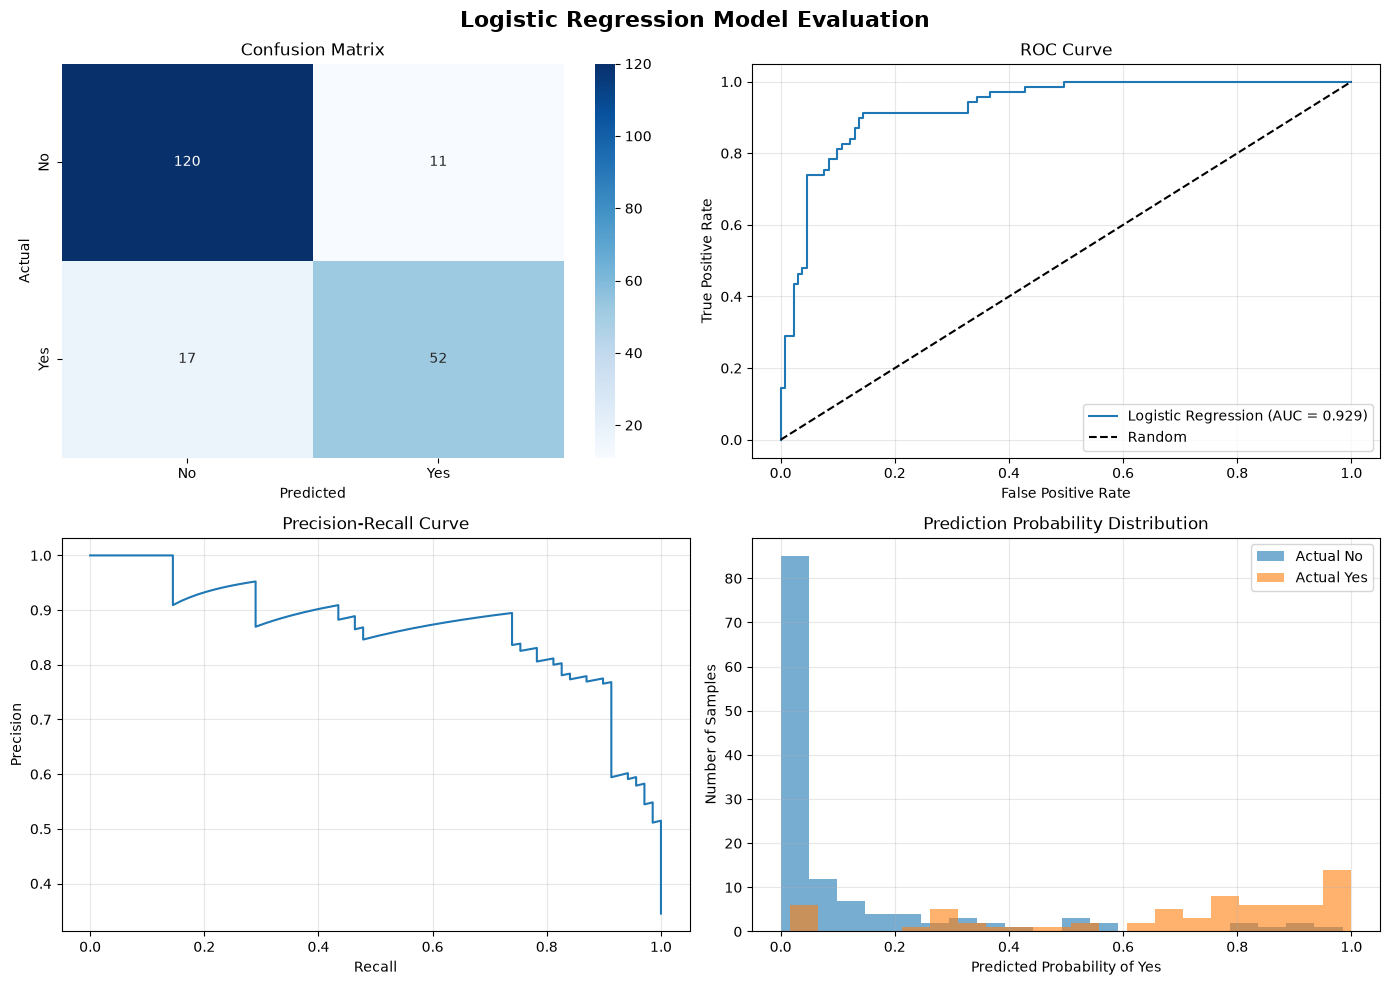

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)


# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# ROC curve
fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob)

# Precision-Recall curve
precision_values, recall_values, pr_thresholds = (
    precision_recall_curve(y_test, y_prob)
)



fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 10)
)


# 1. Confusion Matrix


sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"],
    ax=axes[0, 0]
)

axes[0, 0].set_xlabel("Predicted")
axes[0, 0].set_ylabel("Actual")
axes[0, 0].set_title("Confusion Matrix")



# 2. ROC Curve


axes[0, 1].plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

axes[0, 1].plot(
    [0, 1],
    [0, 1],
    "k--",
    label="Random"
)

axes[0, 1].set_xlabel("False Positive Rate")
axes[0, 1].set_ylabel("True Positive Rate")
axes[0, 1].set_title("ROC Curve")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)



# 3. Precision-Recall Curve


axes[1, 0].plot(
    recall_values,
    precision_values
)

axes[1, 0].set_xlabel("Recall")
axes[1, 0].set_ylabel("Precision")
axes[1, 0].set_title("Precision-Recall Curve")
axes[1, 0].grid(alpha=0.3)


# 4. Probability Distribution

axes[1, 1].hist(
    y_prob[y_test == 0],
    bins=20,
    alpha=0.6,
    label="Actual No"
)

axes[1, 1].hist(
    y_prob[y_test == 1],
    bins=20,
    alpha=0.6,
    label="Actual Yes"
)

axes[1, 1].set_xlabel("Predicted Probability of Yes")
axes[1, 1].set_ylabel("Number of Samples")
axes[1, 1].set_title("Prediction Probability Distribution")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)


# Overall layout

plt.suptitle(
    "Logistic Regression Model Evaluation",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()